# Generación de reseñas de productos con GPT-2

**Mini-proyecto de generación de texto | Grupo Echo**  
**JHON MONTENEGRO · Maestría en Inteligencia Artificial Aplicada, Universidad ICESI**

## 1. Problema, alcance e hipótesis

Este proyecto adapta un GPT-2 preentrenado en español para producir **reseñas sintéticas condicionadas por una valoración de 1 a 5 estrellas**. El caso permite estudiar la adaptación de un modelo generativo a un dominio y explorar ejemplos para pruebas de interfaces. No busca fabricar opiniones de compradores ni verificar propiedades de productos: una continuación puede inventar características y experiencias.

**Pregunta de investigación:** ¿el fine-tuning reduce la perplexity en reseñas no vistas y mejora la correspondencia entre estrellas solicitadas y tono del texto, sin aumentar excesivamente la repetición?

**Hipótesis:** el ajuste reducirá la pérdida frente al modelo base y diferenciará mejor el tono de las valoraciones. El muestreo ofrecerá mayor diversidad que greedy, con un posible costo de coherencia. Estas expectativas se contrastan por separado; una mejora de perplexity no implica que todas se cumplan.

### Objetivos

- Explorar el balance, la longitud y el vocabulario de un corpus de reseñas en español.
- Preparar particiones sin textos normalizados compartidos y construir un contexto de valoración.
- Explicar los logits y la predicción del siguiente token a partir del material de clase.
- Comparar GPT-2 antes y después del ajuste bajo el mismo protocolo.
- Estudiar greedy, top-k y top-p, variando la temperatura.
- Analizar perplexity, tono, diversidad, repetición y similitud con entrenamiento, reconociendo los límites de cada indicador.

### Entorno de la ejecución documentada

La ejecución guardada se realizó en CUDA, con `QUICK_RUN=False`, Python **3.13.15**, PyTorch **2.11.0+cu130**, Transformers **5.17.0**, Datasets **4.8.5**, Accelerate **1.15.0**, pandas **2.2.3**, NumPy **2.1.3**, Matplotlib **3.10.0**, scikit-learn **1.6.1** y huggingface_hub **1.31.0**. La celda de configuración conserva este registro; no se deduce un modelo específico de GPU porque no se guardó ese dato.

El notebook no instala paquetes ni necesita API keys. Para reproducirlo, prepara manualmente un entorno compatible y ejecuta las celdas en orden. CUDA es recomendable para el entrenamiento; `QUICK_RUN=True` permite una prueba reducida, cuyos resultados no equivalen al experimento completo presentado aquí.

In [1]:
def review_prompt(stars, beginning=''):
    if stars not in range(1, 6):
        raise ValueError('La valoracion debe estar entre 1 y 5.')
    return f'Valoracion: {stars}/5\nResena: {beginning}'


def training_text(text, label):
    if label not in range(5):
        raise ValueError('La etiqueta debe estar entre 0 y 4.')
    return review_prompt(label + 1, text)


assert training_text('Entrega puntual.', 4) == 'Valoracion: 5/5\nResena: Entrega puntual.'
assert training_text('No funciona.', 0).startswith('Valoracion: 1/5')
print('Formato de condicionamiento validado.')

Formato de condicionamiento validado.


In [2]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import gc
import json
import math
import re
import time
import platform
import importlib.metadata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as functional
from datasets import Dataset, DatasetDict, load_dataset
from huggingface_hub import HfApi
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, set_seed
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

SEED = 42
QUICK_RUN = False
MODEL_NAME = 'mrm8488/spanish-gpt2'
DATASET_NAME = 'SetFit/amazon_reviews_multi_es'
DATA_REVISION = '16015418b488c9186fce74b058877ea939ca934d'
TRAIN_PER_STAR = 60 if QUICK_RUN else 600
EVAL_PER_STAR = 20 if QUICK_RUN else 100
MAX_LEN = 128
EPOCHS = 1 if QUICK_RUN else 3
MAX_NEW_TOKENS = 50
DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
BATCH_SIZE = 4 if DEVICE == 'cuda' else 1
ACCUMULATION = 4
OUTPUT = Path('resultados_resenas_gpt2')
OUTPUT.mkdir(exist_ok=True)
set_seed(SEED)
VERSIONS = {name: importlib.metadata.version(name) for name in ['torch', 'transformers', 'datasets', 'accelerate', 'pandas', 'numpy', 'matplotlib', 'scikit-learn', 'huggingface-hub']}
MODEL_REVISION = HfApi().model_info(MODEL_NAME).sha
print('Dispositivo:', DEVICE, '| Python:', platform.python_version())
print('Modo rapido:', QUICK_RUN, '| Revision del modelo:', MODEL_REVISION)
display(pd.Series(VERSIONS, name='version'))
if DEVICE != 'cuda':
    print('CPU/MPS: el entrenamiento puede ser lento. Considera QUICK_RUN=True para comprobar el flujo.')

Dispositivo: cuda | Python: 3.13.15
Modo rapido: False | Revision del modelo: fc396ce08c65ea334dcf541de7dc05cac89a29b2


,version
torch,2.11.0+cu130
transformers,5.17.0
datasets,4.8.5
accelerate,1.15.0
pandas,2.2.3
numpy,2.1.3
matplotlib,3.10.0
scikit-learn,1.6.1
huggingface-hub,1.31.0


## 2. Fuente y preparación de los datos

Se utiliza [SetFit/amazon_reviews_multi_es](https://huggingface.co/datasets/SetFit/amazon_reviews_multi_es), una copia en español del corpus Amazon Reviews Multi. Sus archivos `train.jsonl`, `validation.jsonl` y `test.jsonl` contienen `id`, `text`, `label` y `label_text`. El corpus descargado tiene **210.000 registros**: 200.000 de entrenamiento y 5.000 en cada partición de evaluación.

La etiqueta **0 corresponde a 1 estrella y 4 a 5 estrellas**, siguiendo la codificación del corpus original. `label_text` contiene la etiqueta numérica en texto, no una descripción lingüística del sentimiento.

La copia no incluye un catálogo, atributos del producto ni identificadores de comprador o producto utilizables para agrupar. Por tanto, el experimento genera continuaciones de reseñas, **no opiniones verificadas sobre un catálogo**. Tampoco permite afirmar generalización a productos o usuarios nuevos.

### Limpieza y separación

Se conservan las particiones oficiales. Se normalizan espacios y se sustituyen patrones evidentes de URL, correo y contacto como precaución, sin prometer una anonimización completa. Se excluyen textos vacíos, duplicados normalizados, ejemplos con etiquetas contradictorias y textos compartidos entre particiones, dando prioridad a entrenamiento, luego validación y prueba. El submuestreo por estrellas ocurre después de esta limpieza.

La siguiente tabla conserva el registro de cada etapa. Los indicadores de duplicados, conflictos y coincidencias se calculan en momentos diferentes y pueden solaparse; no deben sumarse para reconstruir el total de eliminaciones.

**Licencia:** la ficha de este espejo no declara una licencia explícita. El acceso público no equivale a permiso irrestricto. Deben revisarse las condiciones del corpus original y del espejo antes de reutilizar o redistribuir textos o modelos ajustados. El proyecto no incorpora el corpus al repositorio.

In [3]:
data_files = {split: f'https://huggingface.co/datasets/{DATASET_NAME}/resolve/{DATA_REVISION}/{split}.jsonl' for split in ['train', 'validation', 'test']}
raw = load_dataset('json', data_files=data_files)
print(raw)
assert {'text', 'label', 'id'}.issubset(raw['train'].column_names)


def clean_review(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b', '[EMAIL]', text)
    text = re.sub(r'(?<!\w)(?:\+?\d[\s().-]*){9,}(?!\w)', '[CONTACTO]', text)
    return re.sub(r'\s+', ' ', text).strip()


frames = {}
cleaning_log = []
seen_texts = set()
for split in ['train', 'validation', 'test']:
    frame = raw[split].to_pandas()
    before = len(frame)
    missing = int(frame['text'].isna().sum())
    assert frame['label'].notna().all() and frame['label'].isin(range(5)).all()
    frame['text'] = frame['text'].map(clean_review)
    frame['key'] = frame['text'].str.casefold()
    empty = int(frame['text'].eq('').sum())
    frame = frame[frame['text'].ne('')].copy()
    duplicate_count = int(frame.duplicated('key').sum())
    conflicts = frame.groupby('key')['label'].nunique()
    conflict_keys = set(conflicts[conflicts > 1].index)
    frame = frame[~frame['key'].isin(conflict_keys)].drop_duplicates('key').copy()
    overlap = int(frame['key'].isin(seen_texts).sum())
    frame = frame[~frame['key'].isin(seen_texts)].copy()
    seen_texts.update(frame['key'])
    frame['stars'] = frame['label'].astype(int) + 1
    frame['words'] = frame['text'].str.split().str.len()
    frame['characters'] = frame['text'].str.len()
    frames[split] = frame.reset_index(drop=True)
    cleaning_log.append({'split': split, 'original': before, 'nulos': missing, 'vacios': empty, 'duplicados': duplicate_count, 'textos_etiqueta_conflictiva': len(conflict_keys), 'compartidos_split_previo': overlap, 'limpios': len(frame)})
cleaning_df = pd.DataFrame(cleaning_log)
display(cleaning_df)
display(pd.crosstab(frames['train']['stars'], columns='resenas'))
display(frames['train'].groupby('stars').sample(n=1, random_state=SEED)[['stars', 'text']])
for left, right in [('train', 'validation'), ('train', 'test'), ('validation', 'test')]:
    assert set(frames[left]['key']).isdisjoint(frames[right]['key'])

train.jsonl: reconstructing file:   0%|          |  0.00B / 43.8MB            

train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


,split,original,nulos,vacios,duplicados,textos_etiqueta_conflictiva,compartidos_split_previo,limpios
0,train,200000,0,0,1922,427,0,197651
1,validation,5000,0,0,7,1,47,4945
2,test,5000,0,0,6,1,39,4954


col_0,resenas
stars,
1,39708
2,39792
3,39618
4,39230
5,39303


,stars,text
32057,1,Todavía esperamos el abono. Compramos la impre...
51291,2,El León se rasgo en un golpe q le dio el niño....
107749,3,Llego a su tiempo pero la calidad no es la que...
140305,4,"pensaba que todo el dibujo iba con piedras, pe..."
196259,5,Tengo pensamiento de salir de viaje y necesita...


## 3. Análisis exploratorio y selección de longitud

El EDA examina entrenamiento antes de ajustar el modelo: distribución de estrellas, longitud en palabras y caracteres, cuantiles, términos frecuentes y proporción que excede la ventana de tokens. No se corrigen automáticamente faltas ortográficas ni se eliminan negaciones, porque pueden aportar información sobre tono y valoración.

**Hallazgos de esta ejecución:** no hubo textos nulos ni vacíos. Después de la limpieza quedaron 197.651 reseñas de entrenamiento, 4.945 de validación y 4.954 de prueba. El entrenamiento limpio conserva un balance aproximado: entre 39.230 y 39.792 registros por estrella.

Las reseñas de dos estrellas fueron las más largas en promedio, con **31,4 palabras**, frente a **24,9** en las de cinco estrellas. Las medianas oscilaron entre 20 y 24 palabras, pero la cola incluyó textos de hasta 551 palabras. La figura agrupa longitudes de más de 200 palabras en el último intervalo del histograma; el boxplot omite visualmente los valores atípicos, sin eliminarlos de los datos.

La muestra de tokenización de 3.000 textos tuvo percentiles 50, 90, 95 y 99 de **38, 80, 101 y 161,02 tokens**, incluyendo contexto y EOS. El **2,5 %** excedió `MAX_LEN=128`. Esta ventana cubre la mayor parte de las reseñas y limita el costo, aunque puede cortar matices del grupo más largo. La medición del EDA tokeniza el texto concatenado; la codificación final separa contexto y cuerpo, por lo que los límites pueden variar ligeramente.

La muestra final contiene **3.000 / 500 / 500** reseñas de entrenamiento, validación y prueba: 600 por estrella para aprender y 100 por estrella en cada evaluación. Las métricas describen esta muestra equilibrada, no la distribución real de compras.

Los términos frecuentes orientan la descripción del dominio, pero no demuestran causalidad ni calidad de las reseñas. El balance del corpus es una característica de su construcción, no evidencia de que las cinco valoraciones sean igualmente comunes en el comercio electrónico.

words                                           characters         \
         count  mean   std  min   25%   50%   75%    max      count   mean   
stars                                                                        
1      39708.0  28.6  23.2  2.0  14.0  23.0  35.0  407.0    39708.0  153.8   
2      39792.0  31.4  25.5  2.0  16.0  24.0  39.0  506.0    39792.0  169.1   
3      39618.0  29.0  24.7  2.0  14.0  23.0  36.0  458.0    39618.0  156.5   
4      39230.0  26.3  23.1  2.0  11.0  21.0  32.0  394.0    39230.0  144.5   
5      39303.0  24.9  23.8  2.0  10.0  20.0  30.0  551.0    39303.0  139.4   

                                                
         std   min   25%    50%    75%     max  
stars                                           
1      126.6  16.0  75.0  122.0  189.0  2356.0  
2      139.4  20.0  84.0  132.0  209.0  2898.0  
3      134.0  18.0  73.0  124.0  191.0  2459.0  
4      126.6  16.0  64.0  117.0  176.0  2201.0  
5      132.2  17.0  57.0  112.0  169.0  3086.0

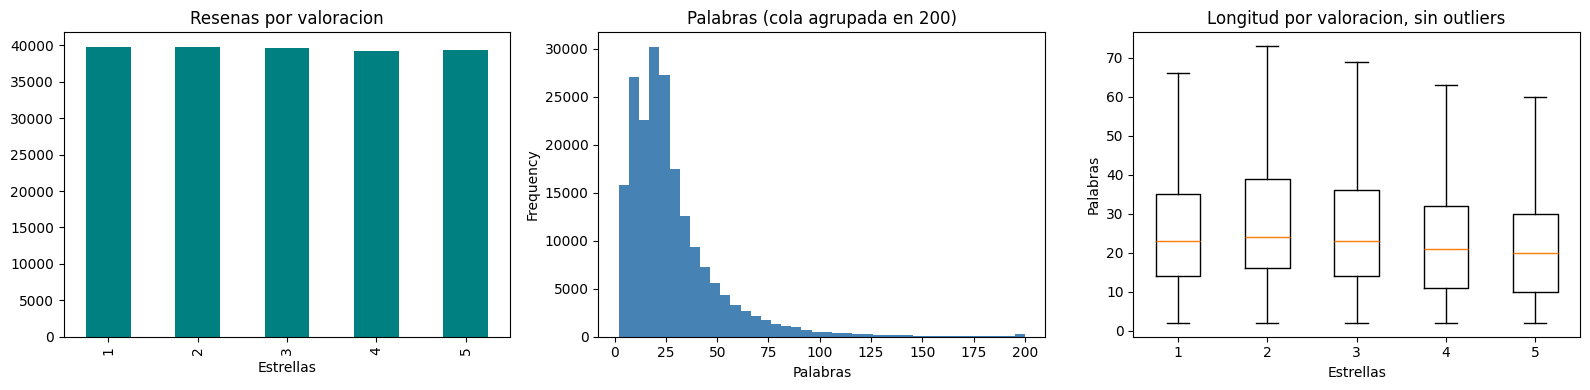

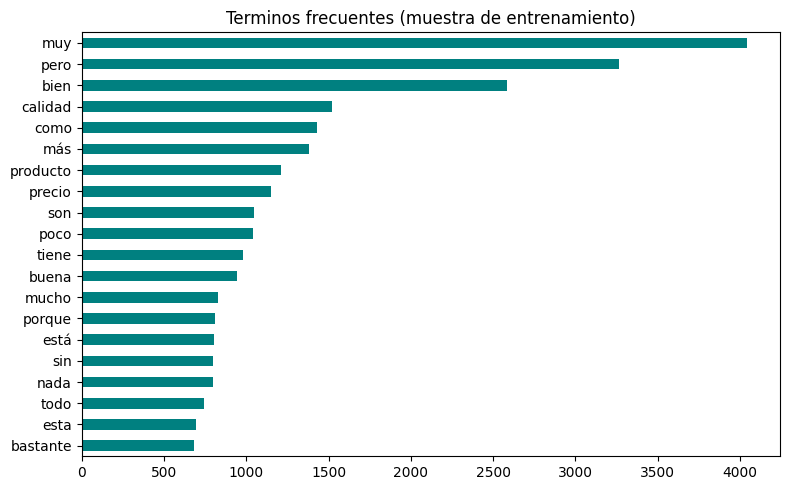

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/846k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/505k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

Cuantiles de tokens con contexto y EOS: [ 38.    80.   101.   161.02]
Textos que exceden MAX_LEN=128: 2.5%


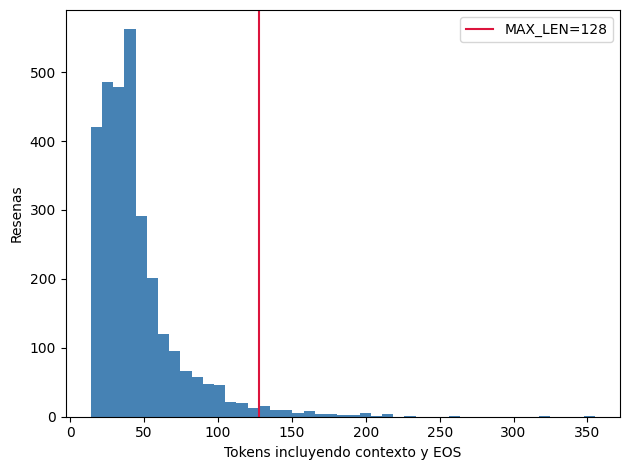

,train,validation,test
stars,,,
1,600,100,100
2,600,100,100
3,600,100,100
4,600,100,100
5,600,100,100


In [4]:
train_eda = frames['train']
display(train_eda.groupby('stars')[['words', 'characters']].describe().round(1))
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
train_eda['stars'].value_counts().sort_index().plot.bar(ax=axes[0], color='teal', title='Resenas por valoracion')
axes[0].set_xlabel('Estrellas')
train_eda['words'].clip(upper=200).plot.hist(bins=40, ax=axes[1], color='steelblue', title='Palabras (cola agrupada en 200)')
axes[1].set_xlabel('Palabras')
axes[2].boxplot([train_eda.loc[train_eda['stars'].eq(stars), 'words'] for stars in range(1, 6)], tick_labels=range(1, 6), showfliers=False)
axes[2].set_title('Longitud por valoracion, sin outliers')
axes[2].set_xlabel('Estrellas')
axes[2].set_ylabel('Palabras')
figure.tight_layout()
figure.savefig(OUTPUT / 'eda_longitudes.png', dpi=150)
plt.show()
stop_words = {'de', 'la', 'el', 'y', 'que', 'en', 'a', 'un', 'una', 'los', 'las', 'del', 'es', 'por', 'para', 'con', 'lo', 'se', 'me', 'mi'}
frequencies = Counter(word for text in train_eda['text'].sample(min(10000, len(train_eda)), random_state=SEED) for word in re.findall(r'\b\w+\b', text.casefold()) if len(word) > 2 and word not in stop_words)
pd.Series(dict(frequencies.most_common(20))).sort_values().plot.barh(figsize=(8, 5), title='Terminos frecuentes (muestra de entrenamiento)', color='teal')
plt.tight_layout()
plt.savefig(OUTPUT / 'eda_vocabulario.png', dpi=150)
plt.show()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
assert tokenizer.eos_token_id is not None
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'
length_sample = train_eda.sample(min(3000, len(train_eda)), random_state=SEED)
lengths = [len(tokenizer.encode(training_text(row.text, row.label), add_special_tokens=False)) + 1 for row in length_sample.itertuples()]
truncation_rate = float(np.mean(np.array(lengths) > MAX_LEN))
print('Cuantiles de tokens con contexto y EOS:', np.quantile(lengths, [0.5, 0.9, 0.95, 0.99]))
print(f'Textos que exceden MAX_LEN={MAX_LEN}: {truncation_rate:.1%}')
plt.hist(lengths, bins=45, color='steelblue')
plt.axvline(MAX_LEN, color='crimson', label=f'MAX_LEN={MAX_LEN}')
plt.xlabel('Tokens incluyendo contexto y EOS')
plt.ylabel('Resenas')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT / 'eda_tokens.png', dpi=150)
plt.show()


def balanced_sample(frame, per_star):
    selected = [group.sample(min(per_star, len(group)), random_state=SEED) for _, group in frame.groupby('stars')]
    return pd.concat(selected).sample(frac=1, random_state=SEED).reset_index(drop=True)


sampled = {split: balanced_sample(frame, TRAIN_PER_STAR if split == 'train' else EVAL_PER_STAR) for split, frame in frames.items()}
display(pd.DataFrame({split: frame['stars'].value_counts().sort_index() for split, frame in sampled.items()}))
for split, frame in sampled.items():
    assert set(frame['stars']) == set(range(1, 6)), f'Faltan estrellas en {split}'

## 4. GPT y objetivo autorregresivo

GPT utiliza bloques **decoder-only con autoatención causal**: la posición $t$ puede atender a posiciones anteriores y a sí misma, pero no al futuro. BERT utiliza representaciones bidireccionales; no es el modelo empleado para generar estas reseñas.

Para una secuencia $x_1,\ldots,x_T$, el entrenamiento minimiza

$$\mathcal{L}=-\frac{1}{N}\sum_{t\in\mathcal{R}}\log p_\theta(x_t\mid x_{<t}),$$

donde $\mathcal{R}$ contiene las posiciones de la reseña y EOS, excluyendo contexto y padding, y $N=|\mathcal{R}|$. En un forward obtenemos logits $(b,s,v)$: tamaño del lote, posiciones y vocabulario. Cada posición predice el siguiente token; para continuar una entrada se utiliza `logits[0, -1, :]`.

Hugging Face desplaza internamente logits y etiquetas. Las etiquetas son iguales a los tokens, con `-100` donde se ignora la pérdida; **no se desplazan por segunda vez**.

Greedy elige $\arg\max_i z_i$. El muestreo utiliza $p_i=\mathrm{softmax}(z_i/\tau)$, con temperatura $\tau>0$. Top-k limita a los k candidatos más probables; top-p conserva un conjunto mínimo cuya probabilidad acumulada alcanza p. Una temperatura baja concentra la distribución; una alta aumenta exploración, no necesariamente calidad.

PAD y EOS comparten identificador, pero el padding se enmascara con `attention_mask`, conservando EOS reales en la pérdida. Un texto truncado **no recibe EOS artificial**, para no enseñar que el corte de ventana es un final natural. La perplexity es $\exp(\mathcal{L})$, calculada bajo el mismo tokenizador y protocolo para ambos modelos.

### Compatibilidad entre tokenizador y embeddings

El checkpoint declara 50.257 embeddings, mientras el tokenizador asigna EOS al ID 50.265. Se amplía el vocabulario a **50.266 embeddings**, se sincronizan EOS/PAD/BOS y se validan IDs y longitudes en CPU antes de usar CUDA. Los embeddings añadidos no tienen el mismo historial de preentrenamiento que los existentes; la comparación utiliza el mismo vocabulario ampliado antes y después del ajuste.

La salida guardada contiene **124.446.720 parámetros** y logits de forma **$(1,16,50266)$** para el ejemplo propio sobre auriculares, ilustrando las dimensiones explicadas en el PDF.

In [5]:
def encode_review(example):
    prefix_ids = tokenizer.encode(review_prompt(int(example['label']) + 1), add_special_tokens=False)
    body_ids = tokenizer.encode(example['text'], add_special_tokens=False)
    budget = MAX_LEN - len(prefix_ids) - 1
    if budget < 1:
        raise ValueError('MAX_LEN no deja espacio para una resena.')
    truncated = len(body_ids) > budget
    body_ids = body_ids[:budget]
    if not truncated:
        body_ids = body_ids + [tokenizer.eos_token_id]
    input_ids = prefix_ids + body_ids
    return {'input_ids': input_ids, 'attention_mask': [1] * len(input_ids), 'labels': [-100] * len(prefix_ids) + body_ids}


def validate_review_tokens(examples, vocabulary_size, max_positions):
    for row_index, row in enumerate(examples):
        input_ids = row['input_ids']
        labels = row['labels']
        attention_mask = row['attention_mask']
        if not input_ids or len(input_ids) > max_positions:
            raise ValueError(f'Ejemplo {row_index}: longitud fuera de la ventana de {max_positions} posiciones.')
        if len(input_ids) != len(labels) or len(input_ids) != len(attention_mask):
            raise ValueError(f'Ejemplo {row_index}: longitudes incompatibles en tokens, etiquetas y mascara.')
        if any(token_id < 0 or token_id >= vocabulary_size for token_id in input_ids):
            raise ValueError(f'Ejemplo {row_index}: input_ids fuera de [0, {vocabulary_size - 1}]. Recarga el modelo y ajusta sus embeddings al tokenizador.')
        if any(label != -100 and (label < 0 or label >= vocabulary_size) for label in labels):
            raise ValueError(f'Ejemplo {row_index}: etiquetas fuera del vocabulario; solo -100 puede ser negativo.')
        if any(value not in (0, 1) for value in attention_mask):
            raise ValueError(f'Ejemplo {row_index}: attention_mask debe contener solo 0 y 1.')


class ReviewCollator:
    def __call__(self, examples):
        if hasattr(self, 'vocabulary_size'):
            validate_review_tokens(examples, self.vocabulary_size, self.max_positions)
        inputs = [{'input_ids': row['input_ids'], 'attention_mask': row['attention_mask']} for row in examples]
        batch = tokenizer.pad(inputs, padding=True, return_tensors='pt')
        padded_labels = torch.full_like(batch['input_ids'], -100)
        for row_index, row in enumerate(examples):
            padded_labels[row_index, :len(row['labels'])] = torch.tensor(row['labels'], dtype=torch.long)
        padded_labels[batch['attention_mask'].eq(0)] = -100
        batch['labels'] = padded_labels
        return batch


collator = ReviewCollator()
tokenized = DatasetDict({split: Dataset.from_pandas(frame[['text', 'label']], preserve_index=False).map(encode_review, remove_columns=['text', 'label']) for split, frame in sampled.items()})
probe_short = encode_review({'text': 'Entrega puntual.', 'label': 4})
probe_long = encode_review({'text': 'Producto. ' * MAX_LEN, 'label': 0})
probe_batch = collator([probe_short, probe_long])
assert probe_short['labels'][-1] == tokenizer.eos_token_id
assert probe_batch['labels'][0, len(probe_short['labels']) - 1].item() == tokenizer.eos_token_id
assert torch.all(probe_batch['labels'][probe_batch['attention_mask'].eq(0)].eq(-100))
assert len(probe_long['input_ids']) <= MAX_LEN
print('Controles de etiquetas, EOS y padding preparados.')
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
original_vocabulary_size = model.get_input_embeddings().num_embeddings
required_vocabulary_size = max(original_vocabulary_size, len(tokenizer), max(tokenizer.get_vocab().values()) + 1)
if required_vocabulary_size > original_vocabulary_size:
    model.resize_token_embeddings(required_vocabulary_size)
    print(f'Embeddings ampliados: {original_vocabulary_size} -> {required_vocabulary_size}; EOS={tokenizer.eos_token_id}.')
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.bos_token_id = tokenizer.bos_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id
model.generation_config.bos_token_id = tokenizer.bos_token_id
collator.vocabulary_size = model.get_input_embeddings().num_embeddings
collator.max_positions = model.config.max_position_embeddings
assert model.get_output_embeddings().weight.shape[0] == collator.vocabulary_size
assert 0 <= tokenizer.pad_token_id < collator.vocabulary_size
assert 0 <= tokenizer.eos_token_id < collator.vocabulary_size
assert MAX_LEN <= collator.max_positions
for split, encoded_dataset in tokenized.items():
    for offset in range(0, len(encoded_dataset), 256):
        validate_review_tokens([encoded_dataset[index] for index in range(offset, min(offset + 256, len(encoded_dataset)))], collator.vocabulary_size, collator.max_positions)
    print(f'{split}: IDs y longitudes validados en CPU antes de usar {DEVICE}.')
model = model.to(DEVICE)
model.eval()
print('Parametros:', f'{sum(parameter.numel() for parameter in model.parameters()):,}')
context = review_prompt(4, 'La bateria de estos auriculares')
inputs = tokenizer(context, return_tensors='pt').to(DEVICE)
with torch.inference_mode():
    logits = model(**inputs).logits
    probabilities = logits[0, -1].softmax(dim=-1)
    top_probabilities, top_ids = probabilities.topk(10)
print('Forma (b, s, v):', tuple(logits.shape))
display(pd.DataFrame({'token': [repr(tokenizer.decode([token_id])) for token_id in top_ids.cpu().tolist()], 'probabilidad': top_probabilities.cpu().tolist()}))

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Controles de etiquetas, EOS y padding preparados.


model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embeddings ampliados: 50257 -> 50266; EOS=50265.
train: IDs y longitudes validados en CPU antes de usar cuda.
validation: IDs y longitudes validados en CPU antes de usar cuda.
test: IDs y longitudes validados en CPU antes de usar cuda.
Parametros: 124,446,720
Forma (b, s, v): (1, 16, 50266)


,token,probabilidad
0,' es',0.120588
1,' se',0.093824
2,"','",0.051254
3,' son',0.045217
4,' no',0.043852
5,' tiene',0.035730
6,' está',0.034057
7,' puede',0.029967
8,' esta',0.021338
9,' debe',0.018966


## 5. Generación incremental y diseño experimental

La función siguiente reproduce la idea pedagógica del notebook guía: inspeccionar probabilidades y añadir un token en cada paso. `greedy_probability=1` explota siempre y `0` muestrea siempre. Esta convención coincide con `eps` del ejemplo de clase, aunque otras definiciones de epsilon-greedy invierten el significado del parámetro. No se realiza aprendizaje por refuerzo.

La comparación sistemática utiliza `model.generate`. El protocolo se fija antes del entrenamiento: **cinco valoraciones, tres inicios, dos semillas y cuatro decodificadores**. Los inicios tratan batería de auriculares, material de una mochila y entrega de un producto; son distintos a los del ejemplo de chistes.

| Método | Muestreo | Temperatura | Restricción |
| --- | --- | --- | --- |
| Greedy | No | No aplica | Token más probable |
| Top-k | Sí | 0,7 | 40 candidatos |
| Top-p | Sí | 0,7 | Probabilidad acumulada 0,9 |
| Top-p | Sí | 1,1 | Probabilidad acumulada 0,9 |

Todas las configuraciones comparten un máximo de **50 tokens nuevos** y penalización de repetición de **1,1**. Se registran semilla, tiempo, tokens, terminación y texto. Se conservan las salidas desfavorables para evitar seleccionar solo ejemplos convenientes.

Hay **120 generaciones por modelo**. Greedy repite la misma salida bajo las dos semillas: se conserva una observación por contexto al resumir, de modo que las métricas de calidad usan 105 observaciones por modelo. Las semillas de muestreo no representan entrenamientos independientes.

Los nombres de productos aparecen únicamente en los inicios de texto. Las métricas no evalúan fidelidad a atributos reales ni experiencias verificadas. La comparación distingue el efecto de ajustar el modelo del efecto de cambiar la decodificación; no introduce una arquitectura diferente.

In [6]:
def incremental_generate(model, prompt, greedy_probability=1.0, steps=12, seed=SEED):
    if not 0 <= greedy_probability <= 1:
        raise ValueError('La probabilidad greedy debe estar entre 0 y 1.')
    set_seed(seed)
    model.eval()
    input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(DEVICE)
    trace = []
    with torch.inference_mode():
        for step in range(steps):
            if input_ids.shape[1] >= model.config.max_position_embeddings:
                break
            probabilities = model(input_ids=input_ids, attention_mask=torch.ones_like(input_ids)).logits[0, -1].softmax(dim=-1)
            best_probs, best_ids = probabilities.topk(5)
            use_greedy = np.random.random() < greedy_probability
            next_id = probabilities.argmax().reshape(1) if use_greedy else torch.multinomial(probabilities, 1)
            trace.append({'paso': step + 1, 'elegido': repr(tokenizer.decode(next_id.cpu().tolist())), 'modo': 'greedy' if use_greedy else 'muestreo', 'candidatos': [(repr(tokenizer.decode([token_id])), round(probability, 4)) for token_id, probability in zip(best_ids.cpu().tolist(), best_probs.cpu().tolist())]})
            input_ids = torch.cat([input_ids, next_id.reshape(1, 1)], dim=1)
            if next_id.item() == tokenizer.eos_token_id:
                break
    return tokenizer.decode(input_ids[0].cpu().tolist(), skip_special_tokens=True), pd.DataFrame(trace)


example_output, trace = incremental_generate(model, context, greedy_probability=0.5)
print(example_output)
display(trace)
DECODERS = {
    'greedy': {'do_sample': False},
    'top_k_40_t07': {'do_sample': True, 'temperature': 0.7, 'top_k': 40, 'top_p': 1.0},
    'top_p09_t07': {'do_sample': True, 'temperature': 0.7, 'top_k': 0, 'top_p': 0.9},
    'top_p09_t11': {'do_sample': True, 'temperature': 1.1, 'top_k': 0, 'top_p': 0.9},
}
BEGINNINGS = ['La bateria de estos auriculares', 'El material de esta mochila', 'La entrega de este producto']
GENERATION_SEEDS = [SEED] if QUICK_RUN else [SEED, SEED + 1]


def generate_review(model, stars, beginning, decoder, seed):
    set_seed(seed)
    model.eval()
    prompt = review_prompt(stars, beginning)
    encoded = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    available = model.config.max_position_embeddings - encoded['input_ids'].shape[1]
    if available <= 0:
        raise ValueError('El contexto supera la ventana del modelo.')
    with torch.inference_mode():
        output_ids = model.generate(**encoded, max_new_tokens=min(MAX_NEW_TOKENS, available), pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id, repetition_penalty=1.1, **DECODERS[decoder])
    continuation = output_ids[0, encoded['input_ids'].shape[1]:].cpu().tolist()
    return {'continuacion': tokenizer.decode(continuation, skip_special_tokens=True).strip(), 'resena': beginning + tokenizer.decode(continuation, skip_special_tokens=True), 'tokens_nuevos': len(continuation), 'termina_eos': bool(continuation and continuation[-1] == tokenizer.eos_token_id)}


def synchronize_device():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    elif DEVICE == 'mps':
        torch.mps.synchronize()


def generation_experiment(model, model_label):
    rows = []
    for stars in range(1, 6):
        for beginning in BEGINNINGS:
            for decoder in DECODERS:
                for seed in GENERATION_SEEDS:
                    synchronize_device()
                    start_time = time.perf_counter()
                    result = generate_review(model, stars, beginning, decoder, seed)
                    synchronize_device()
                    rows.append({'modelo': model_label, 'estrellas': stars, 'inicio': beginning, 'decoder': decoder, 'semilla': seed, 'segundos': time.perf_counter() - start_time, **result})
    return pd.DataFrame(rows)


base_generations = generation_experiment(model, 'base')
base_generations.to_csv(OUTPUT / 'generaciones_base.csv', index=False)
display(base_generations[['estrellas', 'decoder', 'resena']].head(12))

Valoracion: 4/5
Resena: La bateria de estos auriculares es su poro, y el nivel que esta en su


,paso,elegido,modo,candidatos
0,1,' es',greedy,"[(' es', 0.1206), (' se', 0.0938), (',', 0.051..."
1,2,' su',muestreo,"[(' de', 0.403), (' un', 0.0419), (' una', 0.0..."
2,3,' por',muestreo,"[(' instrumento', 0.0208), (' propia', 0.0169)..."
3,4,'o',muestreo,"[('tam', 0.144), ('tadora', 0.1437), ('tab', 0..."
4,5,"','",greedy,"[(',', 0.1258), ('.', 0.0776), (' de', 0.0554)..."
5,6,' y',greedy,"[(' y', 0.0891), (' que', 0.0612), (' el', 0.0..."
6,7,' el',greedy,"[(' el', 0.0856), (' la', 0.0716), (' se', 0.0..."
7,8,' nivel',muestreo,"[(' volumen', 0.0284), (' resto', 0.0247), (' ..."
8,9,' que',muestreo,"[(' de', 0.6515), (' del', 0.0795), (' sonoro'..."
9,10,' esta',muestreo,"[(' se', 0.107), (' tiene', 0.0785), (' tienen..."


,estrellas,decoder,resena
0,1,greedy,"La bateria de estos auriculares es de 2,5 litr..."
1,1,greedy,"La bateria de estos auriculares es de 2,5 litr..."
2,1,top_k_40_t07,La bateria de estos auriculares debe estar aju...
3,1,top_k_40_t07,La bateria de estos auriculares se debe cargar...
4,1,top_p09_t07,La bateria de estos auriculares debe estar aju...
5,1,top_p09_t07,La bateria de estos auriculares se debe cargar...
6,1,top_p09_t11,La bateria de estos auriculares debe ajustarse...
7,1,top_p09_t11,La bateria de estos auriculares se debe especi...
8,1,greedy,El material de esta mochila es de plástico.El ...
9,1,greedy,El material de esta mochila es de plástico.El ...


In [7]:
def token_nll(model, encoded_dataset, ratings):
    if len(encoded_dataset) != len(ratings):
        raise ValueError('Las valoraciones no coinciden con los ejemplos.')
    model.eval()
    totals = {stars: {'nll': 0.0, 'tokens': 0} for stars in range(1, 6)}
    with torch.inference_mode():
        for offset in range(0, len(encoded_dataset), BATCH_SIZE):
            examples = [encoded_dataset[index] for index in range(offset, min(offset + BATCH_SIZE, len(encoded_dataset)))]
            batch = {key: value.to(DEVICE) for key, value in collator(examples).items()}
            logits = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask']).logits[:, :-1].float()
            targets = batch['labels'][:, 1:]
            losses = functional.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1), ignore_index=-100, reduction='none').reshape_as(targets)
            for row_index, stars in enumerate(ratings[offset:offset + len(examples)]):
                valid = targets[row_index].ne(-100)
                totals[int(stars)]['nll'] += float(losses[row_index][valid].sum().cpu())
                totals[int(stars)]['tokens'] += int(valid.sum().cpu())
    rows = []
    for stars, values in totals.items():
        if values['tokens']:
            loss = values['nll'] / values['tokens']
            rows.append({'estrellas': str(stars), 'nll_por_token': loss, 'perplexity': math.exp(loss) if loss < 700 else float('inf'), 'tokens': values['tokens']})
    token_count = sum(values['tokens'] for values in totals.values())
    if not token_count:
        raise ValueError('No hay tokens evaluables.')
    loss = sum(values['nll'] for values in totals.values()) / token_count
    rows.append({'estrellas': 'global', 'nll_por_token': loss, 'perplexity': math.exp(loss) if loss < 700 else float('inf'), 'tokens': token_count})
    return pd.DataFrame(rows)


base_nll = token_nll(model, tokenized['test'], sampled['test']['stars'].tolist())
base_nll['modelo'] = 'base'
display(base_nll)
base_nll.to_csv(OUTPUT / 'perplexity_base.csv', index=False)

,estrellas,nll_por_token,perplexity,tokens,modelo
0,1,5.276631,195.709425,3562,base
1,2,5.216978,184.376131,3754,base
2,3,5.118090,167.015984,3637,base
3,4,5.346400,209.851448,2962,base
4,5,5.234973,187.724052,3284,base
5,global,5.234146,187.568824,17199,base


## 6. Fine-tuning completo y selección del checkpoint

Se ajustan los parámetros de GPT-2 con learning rate **2e-5**, weight decay **0,01** y **tres épocas**. En esta ejecución, el batch por dispositivo fue 4 y la acumulación de gradientes fue 4, para un **batch efectivo de 16** en un solo dispositivo. Gradient checkpointing reduce memoria a costa de cómputo. Se empleó FP16 en CUDA.

El checkpoint se selecciona **solo por pérdida de validación**. No se reajustan hiperparámetros mirando prueba. La pérdida de `Trainer` resume batches y sirve para seleccionar el checkpoint; la evaluación final calcula NLL ponderada por cada token válido de la reseña. Por ello no se comparan ambas cifras como si fueran exactamente el mismo estimador.

La ejecución realizó 564 actualizaciones y tardó aproximadamente **4,4 minutos**. La pérdida de validación disminuyó de 4,370884 en la primera época a 4,305634 y 4,287746. El mejor checkpoint fue el de la tercera época, `checkpoint-564`. Las curvas muestran mejora dentro de este horizonte, con una ganancia menor al final; no permiten afirmar por sí solas qué ocurriría con más entrenamiento.

Para reproducir el experimento, se debe partir otra vez del checkpoint base, no del modelo ya ajustado. En un entorno con menos memoria, modificar batch o acumulación cambia la configuración y debe registrarse. La descarga y los checkpoints pueden ocupar varios GB; CPU/MPS pueden requerir más tiempo y no garantizan equivalencia numérica con CUDA.

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,4.333846,4.370884
2,4.224409,4.305634
3,4.124864,4.287746


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Tiempo de entrenamiento (minutos): 5.42
Mejor checkpoint: resultados_resenas_gpt2/checkpoints/checkpoint-564


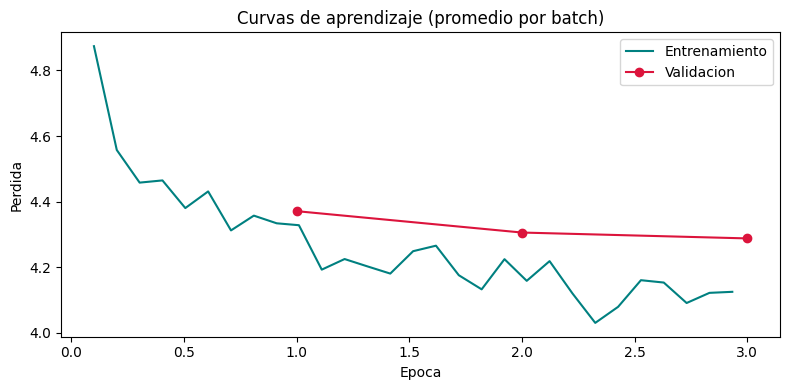

Interpreta divergencias train/validation como posibles indicios de sobreajuste, no como prueba aislada.


In [8]:
set_seed(SEED)
model.config.use_cache = False
training_args = TrainingArguments(
    output_dir=str(OUTPUT / 'checkpoints'),
    num_train_epochs=EPOCHS,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=ACCUMULATION,
    gradient_checkpointing=True,
    fp16=DEVICE == 'cuda',
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=max(1, math.ceil(len(tokenized['train']) / (BATCH_SIZE * ACCUMULATION * 10))),
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    optim='adamw_torch',
    report_to='none',
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=0,
    dataloader_pin_memory=DEVICE == 'cuda',
)
trainer = Trainer(model=model, args=training_args, train_dataset=tokenized['train'], eval_dataset=tokenized['validation'], data_collator=collator)
synchronize_device()
training_start = time.perf_counter()
train_result = trainer.train()
synchronize_device()
training_seconds = time.perf_counter() - training_start
model = trainer.model
model.gradient_checkpointing_disable()
model.config.use_cache = True
model.eval()
trainer.save_model(str(OUTPUT / 'modelo_ajustado'))
tokenizer.save_pretrained(OUTPUT / 'modelo_ajustado')
history = pd.DataFrame(trainer.state.log_history)
history.to_csv(OUTPUT / 'historial_entrenamiento.csv', index=False)
print('Tiempo de entrenamiento (minutos):', round(training_seconds / 60, 2))
print('Mejor checkpoint:', trainer.state.best_model_checkpoint)
figure, axis = plt.subplots(figsize=(8, 4))
if 'loss' in history:
    curve = history.dropna(subset=['loss'])
    axis.plot(curve['epoch'], curve['loss'], label='Entrenamiento', color='teal')
if 'eval_loss' in history:
    curve = history.dropna(subset=['eval_loss'])
    axis.plot(curve['epoch'], curve['eval_loss'], marker='o', label='Validacion', color='crimson')
axis.set(xlabel='Epoca', ylabel='Perdida', title='Curvas de aprendizaje (promedio por batch)')
axis.legend()
figure.tight_layout()
figure.savefig(OUTPUT / 'curvas_entrenamiento.png', dpi=150)
plt.show()
print('Interpreta divergencias train/validation como posibles indicios de sobreajuste, no como prueba aislada.')

In [9]:
finetuned_nll = token_nll(model, tokenized['test'], sampled['test']['stars'].tolist())
finetuned_nll['modelo'] = 'ajustado'
perplexity_comparison = pd.concat([base_nll, finetuned_nll], ignore_index=True)
perplexity_comparison.to_csv(OUTPUT / 'perplexity_comparacion.csv', index=False)
display(perplexity_comparison)
finetuned_generations = generation_experiment(model, 'ajustado')
generations = pd.concat([base_generations, finetuned_generations], ignore_index=True)
generations.to_csv(OUTPUT / 'generaciones_completas.csv', index=False)
paired = base_generations.merge(finetuned_generations, on=['estrellas', 'inicio', 'decoder', 'semilla'], suffixes=('_base', '_ajustado'), validate='one_to_one')
display(paired[['estrellas', 'decoder', 'resena_base', 'resena_ajustado']].head(12))

counterfactual_frame = sampled['test'][['text', 'label']].copy()
counterfactual_frame['label'] = (counterfactual_frame['label'] + 2) % 5
counterfactual_dataset = Dataset.from_pandas(counterfactual_frame, preserve_index=False).map(encode_review, remove_columns=['text', 'label'])
counterfactual_nll = token_nll(model, counterfactual_dataset, sampled['test']['stars'].tolist())
correct_loss = float(finetuned_nll.loc[finetuned_nll['estrellas'].eq('global'), 'nll_por_token'].iloc[0])
wrong_loss = float(counterfactual_nll.loc[counterfactual_nll['estrellas'].eq('global'), 'nll_por_token'].iloc[0])
print(f'NLL contexto correcto: {correct_loss:.4f}; contexto con estrellas cambiadas: {wrong_loss:.4f}; diferencia: {wrong_loss - correct_loss:.4f}')
counterfactual_nll.to_csv(OUTPUT / 'control_estrellas_cambiadas.csv', index=False)
print('Una diferencia positiva sugiere uso del contexto, pero no demuestra obediencia perfecta ni efecto causal de cada estrella.')

,estrellas,nll_por_token,perplexity,tokens,modelo
0,1,5.276631,195.709425,3562,base
1,2,5.216978,184.376131,3754,base
2,3,5.118090,167.015984,3637,base
3,4,5.346400,209.851448,2962,base
4,5,5.234973,187.724052,3284,base
5,global,5.234146,187.568824,17199,base
6,1,4.301951,73.843692,3562,ajustado
7,2,4.259909,70.803562,3754,ajustado
8,3,4.171064,64.784341,3637,ajustado
9,4,4.136239,62.567059,2962,ajustado


,estrellas,decoder,resena_base,resena_ajustado
0,1,greedy,"La bateria de estos auriculares es de 2,5 litr...",La bateria de estos auriculares es muy pequeña...
1,1,greedy,"La bateria de estos auriculares es de 2,5 litr...",La bateria de estos auriculares es muy pequeña...
2,1,top_k_40_t07,La bateria de estos auriculares debe estar aju...,La bateria de estos auriculares no funciona co...
3,1,top_k_40_t07,La bateria de estos auriculares se debe cargar...,La bateria de estos auriculares se ha roto y l...
4,1,top_p09_t07,La bateria de estos auriculares debe estar aju...,La bateria de estos auriculares no funciona. N...
5,1,top_p09_t07,La bateria de estos auriculares se debe cargar...,La bateria de estos auriculares se ha roto y l...
6,1,top_p09_t11,La bateria de estos auriculares debe ajustarse...,La bateria de estos auriculares no la necesita...
7,1,top_p09_t11,La bateria de estos auriculares se debe especi...,La bateria de estos auriculares se ve afectada...
8,1,greedy,El material de esta mochila es de plástico.El ...,"El material de esta mochila es muy bueno, pero..."
9,1,greedy,El material de esta mochila es de plástico.El ...,"El material de esta mochila es muy bueno, pero..."


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

NLL contexto correcto: 4.2115; contexto con estrellas cambiadas: 4.2248; diferencia: 0.0133
Una diferencia positiva sugiere uso del contexto, pero no demuestra obediencia perfecta ni efecto causal de cada estrella.


## 7. Calidad, diversidad y tono: métricas complementarias

- **NLL/perplexity:** capacidad de asignar probabilidad a reseñas de prueba; no mide directamente calidad humana ni verdad factual. Se informa globalmente y por estrellas.
- **Distinct-1/2:** proporción de unigramas o bigramas únicos en las continuaciones, sin contar los inicios compartidos. Depende de longitud y tamaño de muestra.
- **Repetición de trigramas:** $1-\text{trigramas únicos}/\text{trigramas totales}$ por salida. Un texto corto puede puntuar cero aunque sea incoherente.
- **EOS y longitud:** distinguen terminación aprendida del corte por el presupuesto. Una continuación sin texto es vacía aunque contenga EOS.
- **Duplicados entre salidas:** detectan continuaciones idénticas dentro de cada grupo; no equivalen a copiar una reseña de entrenamiento.
- **Sonda de tono:** TF-IDF y regresión logística, entrenados solo con la muestra de entrenamiento, estiman tres grupos: negativas (1–2 estrellas), intermedias (3) y positivas (4–5). Se comprueba primero su desempeño en reseñas reales.

La sonda obtuvo en prueba **accuracy de 0,696 y F1 macro de 0,653**, con F1 de 0,427 para intermedias. Es una medida auxiliar imperfecta, especialmente para esa clase, no un juez independiente de la calidad del generador.

No se utiliza BLEU/ROUGE como criterio principal porque cada inicio admite muchas continuaciones válidas sin una referencia única. No se filtran salidas para mejorar las cifras. Greedy se cuenta una vez por combinación de inicio, estrellas y modelo; los duplicados producidos por muestreo se conservan.

Las tablas permiten comprobar que una menor perplexity puede coexistir con repetición, tono incorrecto o texto inconcluso. Los gráficos y las conclusiones finales interpretan esas dimensiones por separado.

Sonda en resenas reales: validation


,precision,recall,f1-score,support
intermedia,0.379,0.440,0.407,100.000
negativa,0.709,0.695,0.702,200.000
positiva,0.777,0.730,0.753,200.000
accuracy,0.658,0.658,0.658,0.658
macro avg,0.622,0.622,0.621,500.000
weighted avg,0.670,0.658,0.663,500.000


Sonda en resenas reales: test


,precision,recall,f1-score,support
intermedia,0.415,0.440,0.427,100.000
negativa,0.751,0.755,0.753,200.000
positiva,0.793,0.765,0.779,200.000
accuracy,0.696,0.696,0.696,0.696
macro avg,0.653,0.653,0.653,500.000
weighted avg,0.701,0.696,0.698,500.000


,modelo,decoder,muestras,palabras_media,repeticion_3_media,coincidencia_tono,final_eos,vacias,segundos_media,duplicadas,distinct_1,distinct_2
0,ajustado,greedy,15,44.600,0.650,0.533,0.0,0.0,0.737,0.600,0.055,0.096
1,ajustado,top_k_40_t07,30,44.433,0.002,0.333,0.0,0.0,0.692,0.333,0.183,0.403
2,ajustado,top_p09_t07,30,44.467,0.016,0.333,0.0,0.0,0.672,0.267,0.205,0.462
3,ajustado,top_p09_t11,30,38.100,0.000,0.467,0.0,0.0,0.696,0.267,0.239,0.424
4,base,greedy,15,43.400,0.448,0.333,0.0,0.0,0.627,0.467,0.088,0.165
5,base,top_k_40_t07,30,41.333,0.002,0.333,0.0,0.0,0.717,0.467,0.162,0.302
6,base,top_p09_t07,30,39.733,0.050,0.433,0.0,0.0,0.717,0.433,0.173,0.318
7,base,top_p09_t11,30,38.233,0.000,0.300,0.0,0.0,0.694,0.500,0.204,0.334


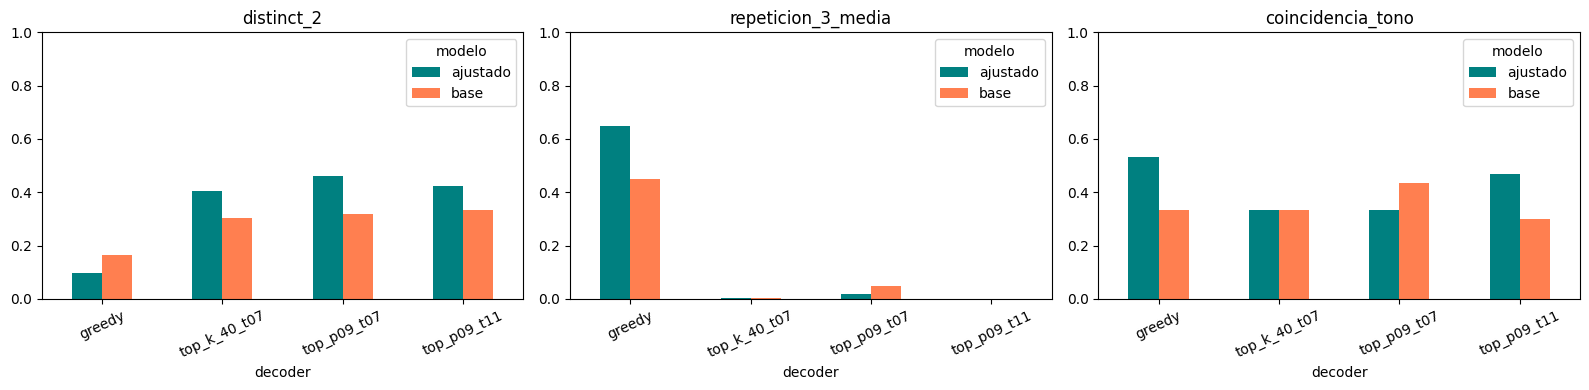

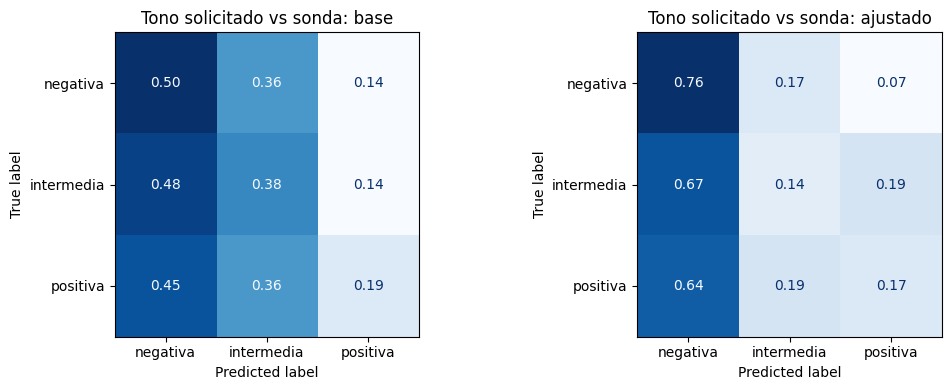

In [10]:
def words_of(text):
    return re.findall(r'\b\w+\b', text.casefold())


def ngrams_of(text, order):
    words = words_of(text)
    return [tuple(words[index:index + order]) for index in range(max(0, len(words) - order + 1))]


def repetition_score(text):
    triples = ngrams_of(text, 3)
    return 1 - len(set(triples)) / len(triples) if triples else 0.0


def tone_of(stars):
    return 'negativa' if stars <= 2 else ('intermedia' if stars == 3 else 'positiva')


vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=30000, sublinear_tf=True)
train_features = vectorizer.fit_transform(sampled['train']['text'])
train_tones = sampled['train']['stars'].map(tone_of)
sentiment_probe = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
sentiment_probe.fit(train_features, train_tones)
probe_reports = {}
for split in ['validation', 'test']:
    predictions = sentiment_probe.predict(vectorizer.transform(sampled[split]['text']))
    true_tones = sampled[split]['stars'].map(tone_of)
    report = classification_report(true_tones, predictions, output_dict=True, zero_division=0)
    probe_reports[split] = report
    print('Sonda en resenas reales:', split)
    display(pd.DataFrame(report).T.round(3))

generations['tono_solicitado'] = generations['estrellas'].map(tone_of)
generations['tono_estimado'] = sentiment_probe.predict(vectorizer.transform(generations['resena']))
generations['coincidencia_tono'] = generations['tono_solicitado'].eq(generations['tono_estimado'])
generations['palabras_nuevas'] = generations['continuacion'].map(lambda text: len(words_of(text)))
generations['repeticion_3'] = generations['continuacion'].map(repetition_score)
generations['vacia'] = generations['continuacion'].str.strip().eq('')
greedy_rows = generations[generations['decoder'].eq('greedy')].drop_duplicates(['modelo', 'estrellas', 'inicio'])
measured = pd.concat([greedy_rows, generations[generations['decoder'].ne('greedy')]], ignore_index=True)


def summarize_generations(group):
    row = {'muestras': len(group), 'palabras_media': group['palabras_nuevas'].mean(), 'repeticion_3_media': group['repeticion_3'].mean(), 'coincidencia_tono': group['coincidencia_tono'].mean(), 'final_eos': group['termina_eos'].mean(), 'vacias': group['vacia'].mean(), 'segundos_media': group['segundos'].mean(), 'duplicadas': group['continuacion'].str.casefold().duplicated().mean()}
    for order in [1, 2]:
        all_ngrams = [item for text in group['continuacion'] for item in ngrams_of(text, order)]
        row[f'distinct_{order}'] = len(set(all_ngrams)) / len(all_ngrams) if all_ngrams else 0.0
    return row


quality_rows = [{'modelo': model_label, 'decoder': decoder, **summarize_generations(group)} for (model_label, decoder), group in measured.groupby(['modelo', 'decoder'])]
quality = pd.DataFrame(quality_rows)
quality.to_csv(OUTPUT / 'metricas_generacion.csv', index=False)
display(quality.round(3))
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, metric in zip(axes, ['distinct_2', 'repeticion_3_media', 'coincidencia_tono']):
    quality.pivot(index='decoder', columns='modelo', values=metric).plot.bar(ax=axis, color=['teal', 'coral'], title=metric, rot=25)
    axis.set_ylim(0, 1)
figure.tight_layout()
figure.savefig(OUTPUT / 'comparacion_decodificadores.png', dpi=150)
plt.show()
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
tone_labels = ['negativa', 'intermedia', 'positiva']
for axis, model_label in zip(axes, ['base', 'ajustado']):
    subset = measured[measured['modelo'].eq(model_label)]
    matrix = confusion_matrix(subset['tono_solicitado'], subset['tono_estimado'], labels=tone_labels, normalize='true')
    ConfusionMatrixDisplay(matrix, display_labels=tone_labels).plot(ax=axis, cmap='Blues', colorbar=False, values_format='.2f')
    axis.set_title(f'Tono solicitado vs sonda: {model_label}')
figure.tight_layout()
figure.savefig(OUTPUT / 'control_tono.png', dpi=150)
plt.show()

## 8. Auditoría de similitud y evaluación humana

Se busca la reseña más similar dentro de la **muestra realmente usada para entrenar**, mediante coseno entre vectores TF-IDF normalizados. La similitud es lexical: no prueba memorización semántica ni audita todo el preentrenamiento. Una coincidencia normalizada exacta constituye una alerta más fuerte; el umbral 0,8 es exploratorio, no un criterio validado. La comparación incluye el inicio de la reseña y el vocabulario TF-IDF está limitado.

En esta ejecución **no hubo coincidencias exactas ni salidas con similitud de 0,8 o mayor**. El mayor coseno mostrado fue **0,373569**, en una continuación sobre entrega. No hay indicios fuertes de copia literal en esta muestra, pero no se demuestra ausencia de memorización ni de paráfrasis.

El análisis de errores muestra continuaciones repetitivas o con tono diferente del solicitado. Los ejemplos se conservan sin corregir retrospectivamente su contenido. Una reseña fluida puede inventar experiencias, y una diversidad alta puede deberse a incoherencia.

Como complemento se generó una plantilla ciega de **24 reseñas**, tres por combinación de modelo y decodificador, con códigos secuenciales asignados después de barajar las filas. La clave identifica modelo y método; la plantilla no los revela. El evaluador puede puntuar coherencia y tono de 1 a 5 y marcar detalles no sustentados (0/1). Se conservan calificaciones existentes solo si corresponden a la misma muestra.

**Estado real:** la celda de resumen informa que no hay puntuaciones humanas completadas. Por tanto, esta ejecución documenta la preparación de la evaluación humana, pero no sus resultados. No se imputaron calificaciones ni se declara un ganador en coherencia humana.

In [11]:
generated_features = vectorizer.transform(generations['resena'])
nearest_scores = []
nearest_indices = []
for row_index in range(generated_features.shape[0]):
    similarities = (generated_features[row_index] @ train_features.T).toarray().ravel()
    nearest_index = int(similarities.argmax())
    nearest_indices.append(nearest_index)
    nearest_scores.append(float(similarities[nearest_index]))
generations['similitud_max_train'] = nearest_scores
generations['indice_train_mas_cercano'] = nearest_indices
train_keys = set(sampled['train']['text'].map(clean_review).str.casefold())
generations['coincidencia_exacta_train'] = generations['resena'].map(clean_review).str.casefold().isin(train_keys)
generations.to_csv(OUTPUT / 'generaciones_con_auditoria.csv', index=False)
display(generations.groupby(['modelo', 'decoder'])[['similitud_max_train', 'coincidencia_exacta_train']].mean().round(3))
most_similar = generations.sort_values('similitud_max_train', ascending=False).head(5).copy()
most_similar['referencia_solo_inspeccion'] = [sampled['train'].iloc[index]['text'] for index in most_similar['indice_train_mas_cercano']]
display(most_similar[['modelo', 'resena', 'similitud_max_train', 'referencia_solo_inspeccion']])
print('Salidas con similitud >= 0.8:', int(generations['similitud_max_train'].ge(0.8).sum()))
errors = generations[generations['vacia'] | generations['repeticion_3'].gt(0.2) | ~generations['coincidencia_tono']]
display(errors[['modelo', 'estrellas', 'decoder', 'resena', 'tono_estimado', 'repeticion_3']].head(15))

human_sample = measured.groupby(['modelo', 'decoder'], group_keys=False).sample(n=3, random_state=SEED).sample(frac=1, random_state=SEED).reset_index(drop=True)
human_sample['codigo'] = [f'R{index + 1:03d}' for index in range(len(human_sample))]
human_key = human_sample[['codigo', 'modelo', 'decoder', 'estrellas', 'inicio', 'semilla']]
human_template_path = OUTPUT / 'evaluacion_humana.csv'
human_key_path = OUTPUT / 'clave_evaluacion_humana.csv'
if human_template_path.exists() or human_key_path.exists():
    if not (human_template_path.exists() and human_key_path.exists()):
        raise ValueError('Falta la plantilla o su clave. Conserva ambas o usa otra carpeta OUTPUT.')
    previous_key = pd.read_csv(human_key_path)
    previous_template = pd.read_csv(human_template_path, keep_default_na=False)
    pd.testing.assert_frame_equal(previous_key, human_key.reset_index(drop=True), check_dtype=False)
    pd.testing.assert_frame_equal(previous_template[['codigo', 'estrellas', 'resena']], human_sample[['codigo', 'estrellas', 'resena']], check_dtype=False)
    print('Se conservan las calificaciones existentes de esta misma muestra.')
else:
    human_template = human_sample[['codigo', 'estrellas', 'resena']].copy()
    for column in ['coherencia_1a5', 'tono_1a5', 'detalles_no_sustentados_0o1', 'observaciones']:
        human_template[column] = ''
    human_key.to_csv(human_key_path, index=False)
    human_template.to_csv(human_template_path, index=False)
print('Completa evaluacion_humana.csv sin consultar la clave; despues ejecuta la siguiente celda.')

similitud_max_train  coincidencia_exacta_train
modelo   decoder                                                     
ajustado greedy                      0.290                        0.0
         top_k_40_t07                0.224                        0.0
         top_p09_t07                 0.239                        0.0
         top_p09_t11                 0.183                        0.0
base     greedy                      0.222                        0.0
         top_k_40_t07                0.194                        0.0
         top_p09_t07                 0.195                        0.0
         top_p09_t11                 0.177                        0.0

,modelo,resena,similitud_max_train,referencia_solo_inspeccion
188,ajustado,La entrega de este producto a la venta no ha l...,0.373569,Sigo esperando 6 días después de la fecha de e...
140,ajustado,La entrega de este producto no ha llegado a ti...,0.339258,El producto no me ha llegado
236,ajustado,La entrega de este producto a la venta no ha l...,0.328883,Sigo esperando 6 días después de la fecha de e...
212,ajustado,La entrega de este producto a la venta no ha l...,0.328883,Sigo esperando 6 días después de la fecha de e...
165,ajustado,La entrega de este producto se retrasó unos dí...,0.321983,"Pedí 2 y hasta la fecha ,solo me ha llegado uno"


Salidas con similitud >= 0.8: 0


,modelo,estrellas,decoder,resena,tono_estimado,repeticion_3
0,base,1,greedy,"La bateria de estos auriculares es de 2,5 litr...",positiva,0.390244
1,base,1,greedy,"La bateria de estos auriculares es de 2,5 litr...",positiva,0.390244
4,base,1,top_p09_t07,La bateria de estos auriculares debe estar aju...,intermedia,0.025641
7,base,1,top_p09_t11,La bateria de estos auriculares se debe especi...,intermedia,0.000000
8,base,1,greedy,El material de esta mochila es de plástico.El ...,intermedia,0.809524
9,base,1,greedy,El material de esta mochila es de plástico.El ...,intermedia,0.809524
11,base,1,top_k_40_t07,El material de esta mochila se debe colocar de...,positiva,0.000000
13,base,1,top_p09_t07,El material de esta mochila se debe especifica...,intermedia,0.458333
14,base,1,top_p09_t11,El material de esta mochila debe ajustarse a s...,intermedia,0.000000
15,base,1,top_p09_t11,El material de esta mochila se debe especifica...,intermedia,0.000000


Completa evaluacion_humana.csv sin consultar la clave; despues ejecuta la siguiente celda.


In [12]:
human_ratings = pd.read_csv(human_template_path)
score_columns = ['coherencia_1a5', 'tono_1a5', 'detalles_no_sustentados_0o1']
for column in score_columns:
    human_ratings[column] = pd.to_numeric(human_ratings[column], errors='coerce')
completed = human_ratings.dropna(subset=score_columns).copy()
if completed.empty:
    print('Evaluacion humana pendiente. No se imputan ni inventan puntuaciones.')
else:
    assert completed['coherencia_1a5'].isin(range(1, 6)).all()
    assert completed['tono_1a5'].isin(range(1, 6)).all()
    assert completed['detalles_no_sustentados_0o1'].isin([0, 1]).all()
    assert not completed['codigo'].duplicated().any()
    assert set(completed['codigo']).issubset(set(human_key['codigo']))
    completed = completed.merge(human_key, on='codigo', validate='one_to_one')
    summary_human = completed.groupby(['modelo', 'decoder'])[score_columns].agg(['mean', 'count'])
    display(summary_human.round(2))
    summary_human.to_csv(OUTPUT / 'resumen_evaluacion_humana.csv')
    print('Interpreta el numero de calificaciones junto con las medias; la muestra es pequena.')

Evaluacion humana pendiente. No se imputan ni inventan puntuaciones.


## 9. Demo interactiva opcional

La demo permite utilizar el checkpoint ajustado con controles de estrellas, inicio, decodificador y semilla, sin servicios de pago ni API externas. El widget quedó mostrado en la ejecución guardada. Eso acredita la creación de la interfaz, no una evaluación adicional de las respuestas ni un registro de todas las interacciones.

Si ipywidgets no está disponible, el código ofrece una llamada equivalente sin instalar paquetes. Cada salida se identifica como **reseña sintética**: cambiar las estrellas no garantiza el tono ni convierte la continuación en una experiencia auténtica. Los ejemplos de la demo no se agregan a las métricas del protocolo experimental.

In [13]:
try:
    import ipywidgets as widgets
except ImportError:
    print('Demo sin widgets: genera una resena cambiando los parametros de esta llamada.')
    print(generate_review(model, 4, 'El material de esta mochila', 'top_p09_t07', SEED)['resena'])
else:
    stars_control = widgets.IntSlider(value=4, min=1, max=5, description='Estrellas:')
    beginning_control = widgets.Text(value='El material de esta mochila', description='Inicio:', layout=widgets.Layout(width='95%'))
    decoder_control = widgets.Dropdown(options=list(DECODERS), value='top_p09_t07', description='Metodo:')
    seed_control = widgets.IntText(value=SEED, description='Semilla:')
    generate_button = widgets.Button(description='Generar', icon='play')
    demo_output = widgets.Output()

    def on_generate_clicked(button):
        generate_button.disabled = True
        try:
            with demo_output:
                demo_output.clear_output()
                print('RESENA SINTETICA - NO ES UNA OPINION REAL')
                result = generate_review(model, stars_control.value, beginning_control.value, decoder_control.value, seed_control.value)
                print(result['resena'])
        except Exception as error:
            with demo_output:
                print(type(error).__name__, str(error))
        finally:
            generate_button.disabled = False

    generate_button.on_click(on_generate_clicked)
    display(widgets.VBox([stars_control, beginning_control, decoder_control, seed_control, generate_button, demo_output]))

In [14]:
config = {
    'seed': SEED, 'quick_run': QUICK_RUN, 'modelo': MODEL_NAME,
    'revision_modelo': MODEL_REVISION, 'dataset': DATASET_NAME, 'revision_dataset': DATA_REVISION,
    'versiones': VERSIONS, 'python': platform.python_version(), 'device': DEVICE,
    'train_per_star': TRAIN_PER_STAR, 'eval_per_star': EVAL_PER_STAR,
    'max_len': MAX_LEN, 'epocas': EPOCHS, 'batch_size': BATCH_SIZE,
    'gradient_accumulation': ACCUMULATION, 'learning_rate': 2e-5,
    'max_new_tokens': MAX_NEW_TOKENS, 'decoders': DECODERS,
    'beginnings': BEGINNINGS, 'generation_seeds': GENERATION_SEEDS,
    'truncamiento_muestra_train': truncation_rate, 'segundos_entrenamiento': training_seconds,
    'best_checkpoint': trainer.state.best_model_checkpoint,
    'diferencia_nll_estrellas_cambiadas': wrong_loss - correct_loss,
    'sample_ids': {split: frame['id'].astype(str).tolist() for split, frame in sampled.items()},
}
with (OUTPUT / 'configuracion.json').open('w', encoding='utf-8') as output_file:
    json.dump(config, output_file, ensure_ascii=False, indent=2)
with (OUTPUT / 'evaluacion_sonda.json').open('w', encoding='utf-8') as output_file:
    json.dump(probe_reports, output_file, ensure_ascii=False, indent=2)
cleaning_df.to_csv(OUTPUT / 'limpieza.csv', index=False)
base_global = float(base_nll.loc[base_nll['estrellas'].eq('global'), 'perplexity'].iloc[0])
tuned_global = float(finetuned_nll.loc[finetuned_nll['estrellas'].eq('global'), 'perplexity'].iloc[0])
relative_change = (tuned_global / base_global - 1) * 100
print(f'Perplexity base: {base_global:.3f}; ajustado: {tuned_global:.3f}; cambio: {relative_change:+.1f}%')
print('La hipotesis de menor perplexity queda', 'respaldada en esta muestra.' if tuned_global < base_global else 'no respaldada en esta muestra.')
print('La hipotesis de control del tono requiere revisar la sonda y la evaluacion humana; no se concluye a partir de perplexity.')
print('Artefactos disponibles:')
for artifact in sorted(OUTPUT.iterdir()):
    if artifact.is_file():
        print(' -', artifact.name)
print('No publiques automaticamente el corpus, checkpoints ni referencias textuales del entrenamiento.')
gc.collect()
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

Perplexity base: 187.569; ajustado: 67.455; cambio: -64.0%
La hipotesis de menor perplexity queda respaldada en esta muestra.
La hipotesis de control del tono requiere revisar la sonda y la evaluacion humana; no se concluye a partir de perplexity.
Artefactos disponibles:
 - clave_evaluacion_humana.csv
 - comparacion_decodificadores.png
 - configuracion.json
 - control_estrellas_cambiadas.csv
 - control_tono.png
 - curvas_entrenamiento.png
 - eda_longitudes.png
 - eda_tokens.png
 - eda_vocabulario.png
 - evaluacion_humana.csv
 - evaluacion_sonda.json
 - generaciones_base.csv
 - generaciones_completas.csv
 - generaciones_con_auditoria.csv
 - historial_entrenamiento.csv
 - limpieza.csv
 - metricas_generacion.csv
 - perplexity_base.csv
 - perplexity_comparacion.csv
No publiques automaticamente el corpus, checkpoints ni referencias textuales del entrenamiento.


## 10. Discusión de resultados y conclusiones

La ejecución completa utilizó CUDA, tres épocas, 3.000 reseñas de entrenamiento y 500 en cada conjunto de validación y prueba. Las conclusiones siguientes se basan en las tablas, figuras y ejemplos guardados, no en resultados esperados.

### Adaptación al dominio

| Indicador en prueba | GPT-2 base | GPT-2 ajustado |
| --- | --- | --- |
| NLL por token | 5,234146 | 4,211462 |
| Perplexity | 187,568824 | 67,455062 |
| Tokens evaluados | 17.199 | 17.199 |

La perplexity disminuyó aproximadamente **64,0 %** bajo el mismo tokenizador y protocolo. La reducción de NLL fue **1,022684 nats por token**. La hipótesis de mejor adaptación probabilística al dominio queda respaldada en esta muestra; no equivale a una mejora del 64 % en coherencia, satisfacción o veracidad.

El entrenamiento tardó aproximadamente **4,4 minutos**. La pérdida de validación fue **4,370884**, **4,305634** y **4,287746** en las épocas 1, 2 y 3. Se seleccionó `checkpoint-564`, de la tercera época. La validación mejoró en cada evaluación, con menor ganancia al final; no se observó un deterioro que permita afirmar sobreajuste dentro de estas tres épocas. Tampoco se demuestra que más entrenamiento mantendría esa mejora.

Los ejemplos guardados muestran un cambio de registro. El modelo base produce descripciones e instrucciones genéricas; al hablar de una batería llega a introducir magnitudes poco apropiadas. El ajustado utiliza expresiones como «no funciona» y «se ha roto», más cercanas a opiniones de compradores. Sin embargo, persisten respuestas poco coherentes y frases positivas en contextos de baja valoración.

### Condicionamiento por estrellas

La NLL fue **4,2115** con las estrellas correctas y **4,2248** al cambiarlas sistemáticamente. La diferencia de **0,0133 nats por token** es positiva, pero pequeña: sugiere sensibilidad al contexto, no control fuerte ni obediencia perfecta. No se realizaron pruebas de significancia ni se entrenaron modelos independientes con y sin condicionamiento.

La sonda obtuvo **accuracy de 0,696** y **F1 macro de 0,653** en reseñas reales de prueba. Su F1 fue 0,753 en negativas, 0,779 en positivas y solo 0,427 en intermedias. Estos errores limitan el alcance de la coincidencia estimada de tono.

El ajuste mejoró esa coincidencia de 0,333 a 0,533 con greedy y de 0,300 a 0,467 con top-p a temperatura 1,1; permaneció en 0,333 con top-k y cayó de 0,433 a 0,333 con top-p a temperatura 0,7. **La hipótesis de mejor control del tono no queda respaldada de manera consistente.**

### Diversidad y repetición

Las 240 salidas originales incluyen dos ejecuciones greedy por contexto. Al resumir se conserva una sola, dejando **105 observaciones por modelo**: 15 greedy y 30 por cada decodificador de muestreo. No son múltiples entrenamientos independientes.

| Modelo | Decodificación | Distinct-2 | Repetición de trigramas | Coincidencia de tono | Salidas duplicadas |
| --- | --- | --- | --- | --- | --- |
| Base | Greedy | 0,165 | 0,448 | 0,333 | 0,467 |
| Ajustado | Greedy | 0,096 | 0,650 | 0,533 | 0,600 |
| Base | Top-k 40, temperatura 0,7 | 0,302 | 0,002 | 0,333 | 0,467 |
| Ajustado | Top-k 40, temperatura 0,7 | 0,403 | 0,002 | 0,333 | 0,333 |
| Base | Top-p 0,9, temperatura 0,7 | 0,318 | 0,050 | 0,433 | 0,433 |
| Ajustado | Top-p 0,9, temperatura 0,7 | 0,462 | 0,016 | 0,333 | 0,267 |
| Base | Top-p 0,9, temperatura 1,1 | 0,334 | 0,000 | 0,300 | 0,500 |
| Ajustado | Top-p 0,9, temperatura 1,1 | 0,424 | 0,000 | 0,467 | 0,267 |

Greedy es el caso más desfavorable: después del ajuste aumenta la repetición y disminuye la diversidad. Por tanto, **no se cumple de forma general la expectativa de mejorar sin aumentar la repetición**. El muestreo ofrece un compromiso más favorable en estas medidas.

Top-p a temperatura 0,7 produjo el mayor Distinct-2 del ajustado, pero una coincidencia de tono de solo 0,333. Top-p a temperatura 1,1 combinó Distinct-2 de 0,424, repetición de trigramas de 0 y coincidencia de tono de 0,467. Es una elección exploratoria razonable cuando se prioriza ese equilibrio, **no un ganador demostrado en coherencia humana**. La ausencia de trigramas repetidos dentro de un texto no impide que varias salidas sean idénticas entre sí.

**Ninguna salida terminó por EOS** y no hubo continuaciones vacías. Las generaciones finalizaron por el límite de tokens, no por un final aprendido de reseña. Este resultado limita su utilidad: un texto fluido puede quedar inconcluso. EOS pertenece a los embeddings ampliados y no comparte el historial completo de los tokens preentrenados; el experimento no permite atribuir la falta de terminación a una causa única.

### Similitud y evaluación humana

No hubo coincidencias normalizadas exactas con las 3.000 reseñas de entrenamiento ni similitudes de 0,8 o superiores. El mayor coseno mostrado fue **0,373569**. Las similitudes medias del ajustado variaron de 0,183 a 0,290 según el método. **No hay indicios fuertes de copia literal en esta muestra**, pero la auditoría lexical no descarta paráfrasis ni coincidencias con datos desconocidos de preentrenamiento.

Se preparó una muestra ciega de **24 reseñas**, pero la salida guardada del resumen indica que **no hay puntuaciones humanas completadas**. La ejecución técnica finalizó; esa extensión no tiene resultados cuantitativos. No se inventaron calificaciones ni se presentan promedios de coherencia humana.

### Conclusión general

Un ajuste breve de GPT-2 sobre reseñas cambia el registro y mejora sustancialmente la probabilidad asignada a textos del mismo dominio. Sin embargo, **adaptar el estilo no equivale a controlar las estrellas, producir reseñas completas ni garantizar fidelidad factual**. La mejora de perplexity convive con repetición en greedy, control irregular del tono y ausencia de terminación por EOS.

El caso propio amplía el ejercicio de clase con condicionamiento por valoración, deduplicación entre particiones, EDA en palabras y tokens, comparación antes/después, cuatro configuraciones de decodificación y análisis complementario de tono y similitud. Estas evidencias permiten responder la pregunta de investigación sin presentar el generador como una fuente de opiniones auténticas.

## Referencias

- Radford et al. (2018). [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf).
- Keung et al. (2020). [The Multilingual Amazon Reviews Corpus](https://aclanthology.org/2020.emnlp-main.369/).
- [Corpus utilizado: SetFit/amazon_reviews_multi_es](https://huggingface.co/datasets/SetFit/amazon_reviews_multi_es).
- [Modelo mrm8488/spanish-gpt2](https://huggingface.co/mrm8488/spanish-gpt2).
- [Documentación de generación de Transformers](https://huggingface.co/docs/transformers/en/main_classes/text_generation).
- [Documentación de Trainer](https://huggingface.co/docs/transformers/en/main_classes/trainer).